# Notebook 06 — U-Net for Satellite Image Change Detection

## Objective

The goal of this notebook is to train a deep learning segmentation model for binary satellite image change detection.

The model is based on the U-Net architecture, which is widely used for image segmentation tasks.

Input:

- RGB before image,
- RGB after image,

combined into a 6-channel tensor.

Output:

- binary change mask.

Compared to previous methods, U-Net can learn spatial patterns directly from data and is expected to better capture building-level structures.

# 1. Imports


In [16]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

# 2. GPU check

In [17]:
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.18.0
GPUs: []


W0000 00:00:1779972610.730145   21428 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# 3. Paths and parameters

In [18]:
DATA_PATH = "../data/raw"

TRAIN_PATH = os.path.join(DATA_PATH, "train")
VAL_PATH = os.path.join(DATA_PATH, "val")
TEST_PATH = os.path.join(DATA_PATH, "test")

IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# 4. Load sample

In [19]:
def load_sample(split_path, filename):
    before = cv2.imread(
        os.path.join(split_path, "A", filename)
    )

    after = cv2.imread(
        os.path.join(split_path, "B", filename)
    )

    mask = cv2.imread(
        os.path.join(split_path, "label", filename),
        cv2.IMREAD_GRAYSCALE
    )

    before = cv2.cvtColor(before, cv2.COLOR_BGR2RGB)
    after = cv2.cvtColor(after, cv2.COLOR_BGR2RGB)

    mask = (mask > 0).astype(np.float32)

    return before, after, mask

# 5. Random crop function

In [20]:
def random_crop(before, after, mask, crop_size=256):
    h, w = mask.shape

    y = np.random.randint(0, h - crop_size + 1)
    x = np.random.randint(0, w - crop_size + 1)

    before_crop = before[y:y+crop_size, x:x+crop_size]
    after_crop = after[y:y+crop_size, x:x+crop_size]
    mask_crop = mask[y:y+crop_size, x:x+crop_size]

    return before_crop, after_crop, mask_crop

# 6. Preprocess crop

In [21]:
def preprocess_pair(before, after, mask):
    before = before.astype(np.float32) / 255.0
    after = after.astype(np.float32) / 255.0

    x = np.concatenate(
        [before, after],
        axis=-1
    )

    y = mask[..., np.newaxis].astype(np.float32)

    return x, y

# 7. Data generator

In [22]:
class ChangeDetectionGenerator(keras.utils.Sequence):

    def __init__(
        self,
        split_path,
        batch_size=4,
        crop_size=256,
        steps_per_epoch=100,
        shuffle=True
    ):
        self.split_path = split_path
        self.batch_size = batch_size
        self.crop_size = crop_size
        self.steps_per_epoch = steps_per_epoch
        self.shuffle = shuffle

        self.files = sorted(
            os.listdir(
                os.path.join(split_path, "A")
            )
        )

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        X_batch = []
        y_batch = []

        for _ in range(self.batch_size):
            filename = np.random.choice(self.files)

            before, after, mask = load_sample(
                self.split_path,
                filename
            )

            before_crop, after_crop, mask_crop = random_crop(
                before,
                after,
                mask,
                crop_size=self.crop_size
            )

            x, y = preprocess_pair(
                before_crop,
                after_crop,
                mask_crop
            )

            X_batch.append(x)
            y_batch.append(y)

        return np.array(X_batch), np.array(y_batch)

# 8. Create generators

In [23]:
train_gen = ChangeDetectionGenerator(
    TRAIN_PATH,
    batch_size=BATCH_SIZE,
    crop_size=IMG_SIZE,
    steps_per_epoch=100
)

val_gen = ChangeDetectionGenerator(
    VAL_PATH,
    batch_size=BATCH_SIZE,
    crop_size=IMG_SIZE,
    steps_per_epoch=30
)

# 9. Visualize training batch

X batch: (4, 256, 256, 6)
y batch: (4, 256, 256, 1)


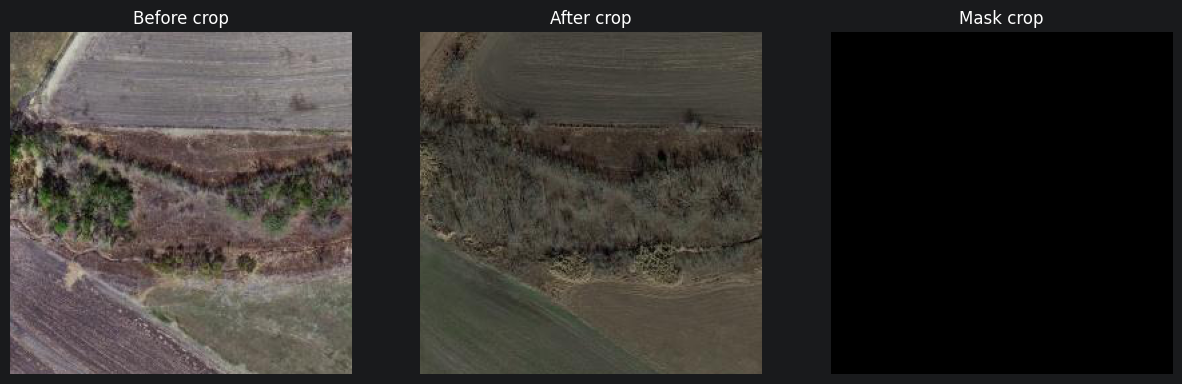

In [24]:
X_batch, y_batch = train_gen[0]

print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

idx = 0

before_img = X_batch[idx, :, :, :3]
after_img = X_batch[idx, :, :, 3:]
mask_img = y_batch[idx, :, :, 0]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(before_img)
ax[0].set_title("Before crop")
ax[0].axis("off")

ax[1].imshow(after_img)
ax[1].set_title("After crop")
ax[1].axis("off")

ax[2].imshow(mask_img, cmap="gray")
ax[2].set_title("Mask crop")
ax[2].axis("off")

plt.show()

# 10. U-Net model

In [25]:
def conv_block(x, filters):
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x


def build_unet(input_shape=(256, 256, 6)):
    inputs = keras.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = conv_block(p3, 256)

    # Decoder
    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.Concatenate()([u5, c3])
    c5 = conv_block(u5, 128)

    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.Concatenate()([u6, c2])
    c6 = conv_block(u6, 64)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.Concatenate()([u7, c1])
    c7 = conv_block(u7, 32)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c7)

    model = keras.Model(
        inputs,
        outputs
    )

    return model

# 11. Dice coefficient and IoU metric

In [26]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(
        y_true_f * y_pred_f
    )

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true_f)
        + tf.reduce_sum(y_pred_f)
        + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return bce + dice_loss(
        y_true,
        y_pred
    )

# 12. Compile model

In [27]:
model = build_unet(
    input_shape=(IMG_SIZE, IMG_SIZE, 6)
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        "accuracy"
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,760 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_9[0][0]  

 Total params: 1,947,745 (7.43 MB)

 Trainable params: 1,947,745 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

# 13. Train model

In [28]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "../outputs/best_unet_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

In [29]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

/home/wojtek/PycharmProjects/satellite-image-change-detection/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.9508 - dice_coef: 0.0502 - loss: 1.2392 - val_accuracy: 0.9601 - val_dice_coef: 0.0271 - val_loss: 1.1784
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9505 - dice_coef: 0.0492 - loss: 1.1752 - val_accuracy: 0.9472 - val_dice_coef: 0.0485 - val_loss: 1.1767
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9550 - dice_coef: 0.0639 - loss: 1.1278 - val_accuracy: 0.9546 - val_dice_coef: 0.0936 - val_loss: 1.1214
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9570 - dice_coef: 0.0934 - loss: 1.0794 - val_accuracy: 0.9609 - val_dice_coef: 0.1270 - val_loss: 1.0048
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9587 - dice_coef: 0.1562 - loss: 0.9905 - val_accuracy: 0.9589 - val_dice_coef: 0.1292 - val_loss: 0.9862
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9312 - dice_coef: 0.2040 - loss: 0.9671 - val_accuracy: 0.9441 - val

# 14. Plot learning curves

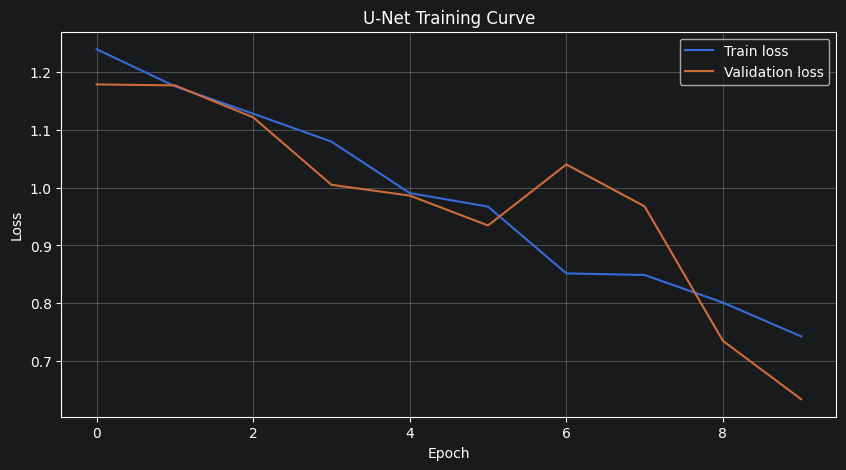

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Train loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Training Curve")
plt.legend()
plt.grid()

plt.show()

In [31]:
def random_crop_with_change(
    before,
    after,
    mask,
    crop_size=256,
    min_change_pixels=50,
    max_attempts=100
):
    """
    Returns a random crop that contains at least min_change_pixels changed pixels.
    If no such crop is found, returns a normal random crop.
    """

    h, w = mask.shape

    for _ in range(max_attempts):

        y = np.random.randint(
            0,
            h - crop_size + 1
        )

        x = np.random.randint(
            0,
            w - crop_size + 1
        )

        before_crop = before[
            y:y+crop_size,
            x:x+crop_size
        ]

        after_crop = after[
            y:y+crop_size,
            x:x+crop_size
        ]

        mask_crop = mask[
            y:y+crop_size,
            x:x+crop_size
        ]

        if mask_crop.sum() >= min_change_pixels:

            return before_crop, after_crop, mask_crop

    return random_crop(
        before,
        after,
        mask,
        crop_size=crop_size
    )

# 15. Predict on one test crop

In [32]:
test_file = sorted(
    os.listdir(
        os.path.join(TEST_PATH, "A")
    )
)[0]

before, after, mask = load_sample(
    TEST_PATH,
    test_file
)

before_crop, after_crop, mask_crop = random_crop_with_change(
    before,
    after,
    mask,
    crop_size=IMG_SIZE,
    min_change_pixels=50
)

x_test, y_test = preprocess_pair(
    before_crop,
    after_crop,
    mask_crop
)

pred_proba = model.predict(
    x_test[np.newaxis, ...]
)[0, :, :, 0]

print("Mask changed pixels:", mask_crop.sum())
print("Probability min:", pred_proba.min())
print("Probability max:", pred_proba.max())
print("Probability mean:", pred_proba.mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
Mask changed pixels: 10059.0
Probability min: 8.865854e-05
Probability max: 0.973689
Probability mean: 0.102859885


In [33]:
thresholds = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
]

unet_threshold_results = []

for threshold in thresholds:

    pred_mask = (
        pred_proba > threshold
    ).astype(np.uint8)

    y_true = mask_crop.flatten().astype(np.uint8)
    y_pred = pred_mask.flatten().astype(np.uint8)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    iou = jaccard_score(
        y_true,
        y_pred,
        zero_division=0
    )

    unet_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou
    })

unet_threshold_results = pd.DataFrame(
    unet_threshold_results
)

unet_threshold_results

,threshold,precision,recall,f1,iou
0,0.1,0.417480,0.616363,0.497792,0.331374
1,0.2,0.530150,0.423899,0.471108,0.308137
2,0.3,0.568527,0.353415,0.435875,0.278671
3,0.4,0.590103,0.314147,0.410017,0.257875
4,0.5,0.606632,0.278258,0.381517,0.235725


In [34]:
best_unet_row = unet_threshold_results.loc[
    unet_threshold_results["iou"].idxmax()
]

best_unet_threshold = best_unet_row["threshold"]

best_unet_row

threshold    0.100000
precision    0.417480
recall       0.616363
f1           0.497792
iou          0.331374
Name: 0, dtype: float64

# 16. Visualize crop prediction

In [35]:
pred_mask = (
    pred_proba > best_unet_threshold
).astype(np.uint8)

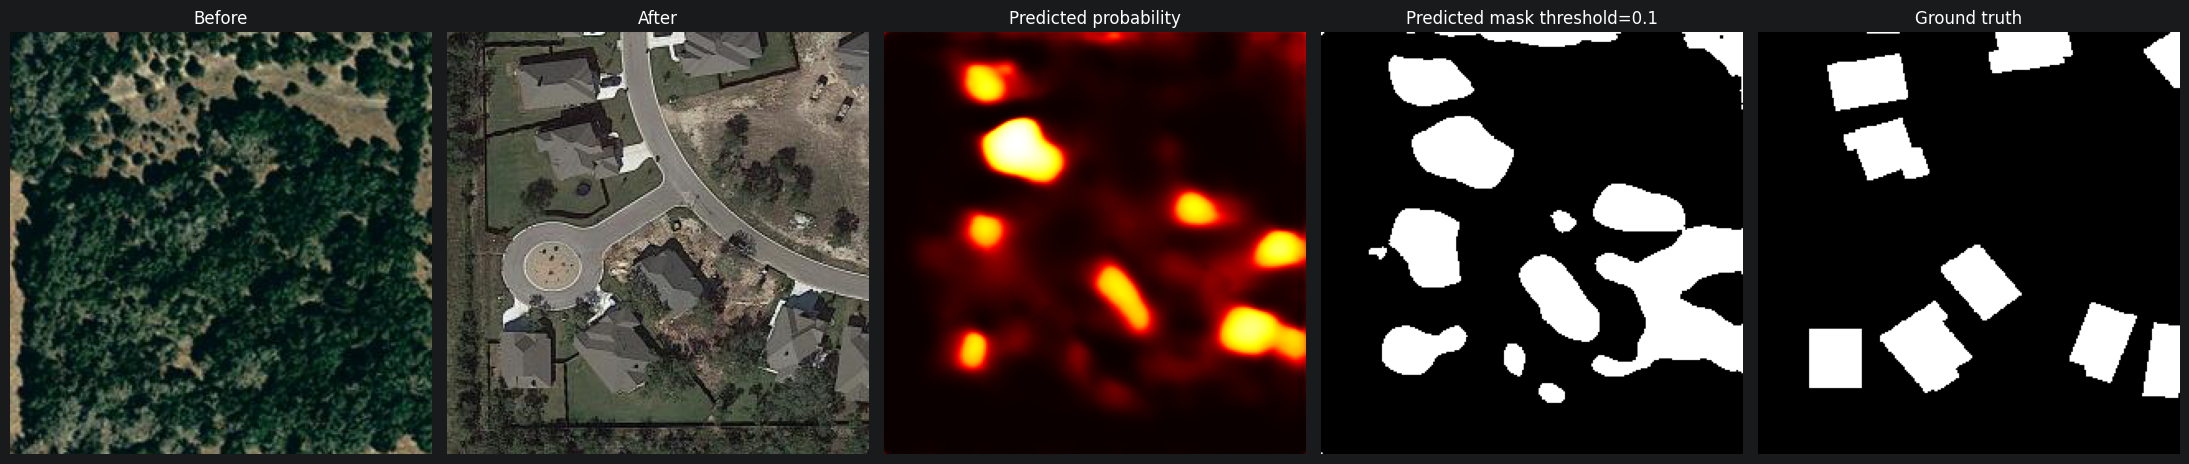

In [36]:
fig, ax = plt.subplots(
    1,
    5,
    figsize=(22, 5)
)

ax[0].imshow(before_crop)
ax[0].set_title("Before")

ax[1].imshow(after_crop)
ax[1].set_title("After")

ax[2].imshow(
    pred_proba,
    cmap="hot"
)
ax[2].set_title("Predicted probability")

ax[3].imshow(
    pred_mask,
    cmap="gray"
)
ax[3].set_title(
    f"Predicted mask threshold={best_unet_threshold}"
)

ax[4].imshow(
    mask_crop,
    cmap="gray"
)
ax[4].set_title("Ground truth")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# 17. Evaluate crop prediction

In [37]:
y_true = mask_crop.flatten().astype(np.uint8)
y_pred = pred_mask.flatten().astype(np.uint8)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

iou = jaccard_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("IoU:", iou)

Precision: 0.417480304356609
Recall: 0.6163634556118899
F1: 0.49779205138498595
IoU: 0.33137359700694813


In [38]:
pd.DataFrame(history.history)

,accuracy,dice_coef,loss,val_accuracy,val_dice_coef,val_loss
0,0.950844,0.050238,1.239244,0.960087,0.027078,1.178372
1,0.950520,0.049209,1.175169,0.947216,0.048465,1.176715
2,0.955026,0.063889,1.127770,0.954648,0.093618,1.121433
3,0.956962,0.093412,1.079447,0.960899,0.127003,1.004806
4,0.958722,0.156170,0.990489,0.958903,0.129215,0.986161
5,0.931163,0.204001,0.967112,0.944091,0.207350,0.934537
6,0.943940,0.304596,0.851662,0.947113,0.178379,1.040053
7,0.940124,0.311410,0.848880,0.877465,0.276321,0.967517
8,0.950061,0.344713,0.801201,0.953349,0.383076,0.735092
9,0.952791,0.410685,0.742702,0.965609,0.465041,0.634085


In [39]:
print("Mask changed pixels:", mask_crop.sum())
print("Probability min:", pred_proba.min())
print("Probability max:", pred_proba.max())
print("Probability mean:", pred_proba.mean())

Mask changed pixels: 10059.0
Probability min: 8.865854e-05
Probability max: 0.973689
Probability mean: 0.102859885


In [40]:
unet_threshold_results

,threshold,precision,recall,f1,iou
0,0.1,0.417480,0.616363,0.497792,0.331374
1,0.2,0.530150,0.423899,0.471108,0.308137
2,0.3,0.568527,0.353415,0.435875,0.278671
3,0.4,0.590103,0.314147,0.410017,0.257875
4,0.5,0.606632,0.278258,0.381517,0.235725


In [41]:
def evaluate_unet_on_positive_crops(
    model,
    split_path,
    num_crops=20,
    threshold=0.1,
    crop_size=256,
    min_change_pixels=50
):
    files = sorted(
        os.listdir(
            os.path.join(split_path, "A")
        )
    )

    results = []

    for i in range(num_crops):

        filename = np.random.choice(files)

        before, after, mask = load_sample(
            split_path,
            filename
        )

        before_crop, after_crop, mask_crop = random_crop_with_change(
            before,
            after,
            mask,
            crop_size=crop_size,
            min_change_pixels=min_change_pixels
        )

        x_test, _ = preprocess_pair(
            before_crop,
            after_crop,
            mask_crop
        )

        pred_proba = model(
            x_test[np.newaxis, ...],
            training=False
        ).numpy()[0, :, :, 0]

        pred_mask = (
            pred_proba > threshold
        ).astype(np.uint8)

        y_true = mask_crop.flatten().astype(np.uint8)
        y_pred = pred_mask.flatten().astype(np.uint8)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        iou = jaccard_score(
            y_true,
            y_pred,
            zero_division=0
        )

        results.append({
            "image": filename,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "iou": iou
        })

    return pd.DataFrame(results)

In [42]:
unet_eval_df = evaluate_unet_on_positive_crops(
    model,
    TEST_PATH,
    num_crops=20,
    threshold=0.1,
    crop_size=IMG_SIZE,
    min_change_pixels=50
)

unet_eval_df

,image,precision,recall,f1,iou
0,test_34.png,0.596917,0.785605,0.678385,0.513300
1,test_112.png,0.733925,0.945714,0.826467,0.704255
2,test_58.png,0.000000,0.000000,0.000000,0.000000
3,test_32.png,0.140099,0.738911,0.235540,0.133491
4,test_81.png,0.127166,0.914330,0.223279,0.125669
5,test_11.png,0.357598,0.934314,0.517232,0.348829
6,test_76.png,0.118037,0.306897,0.170498,0.093194
7,test_25.png,0.497031,0.921806,0.645833,0.476923
8,test_79.png,0.611374,0.443604,0.514149,0.346030
9,test_37.png,0.446577,0.845198,0.584384,0.412812


In [43]:
unet_summary = pd.DataFrame({
    "method": ["U-Net"],
    "threshold": [0.1],
    "num_test_crops": [len(unet_eval_df)],
    "precision": [unet_eval_df["precision"].mean()],
    "recall": [unet_eval_df["recall"].mean()],
    "f1": [unet_eval_df["f1"].mean()],
    "iou": [unet_eval_df["iou"].mean()]
})

unet_summary.round(4)

,method,threshold,num_test_crops,precision,recall,f1,iou
0,U-Net,0.1,20,0.4151,0.6063,0.4507,0.3314


## Conclusions

The U-Net model achieved the best performance among all tested approaches.

Compared to classical computer vision methods and Random Forest baselines, U-Net produced more spatially coherent predictions and better captured building-level changes.

The model achieved the following average results on positive test crops:

| Method | Precision | Recall | F1 | IoU |
|--------|----------:|-------:|---:|----:|
| U-Net | 0.4151 | 0.6063 | 0.4507 | 0.3314 |

This confirms that deep learning segmentation models are better suited for satellite image change detection than simple image differencing or classical machine learning methods.

However, the model still has limitations. Some false positives remain in areas affected by vegetation, shadows, roads, or ambiguous visual changes. Some difficult crops also produced very low IoU.

Future improvements could include:

- training for more epochs,
- using data augmentation,
- using more training crops,
- experimenting with focal loss or weighted BCE,
- full-image tiled inference,
- deploying the model through an API.